# L18 · Variational Autoencoders

*Companion notebook for Lecture 18 — Variational Autoencoders (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Compute the KL divergence between two Gaussians in closed form and check it by Monte Carlo.
2. Implement a VAE in PyTorch with an **explicit** reparameterization step $\mathbf z = \boldsymbol\mu + \boldsymbol\sigma\odot\boldsymbol\epsilon$ and the closed-form KL term.
3. Compare a plain autoencoder (L17) and a VAE on single-cell data (PBMC3k): 2-D codes, prior samples, UMAPs, cell-type accuracy.
4. Measure how the KL weight β trades reconstruction against latent regularity, and observe posterior collapse (active units).
5. *(CS284A)* Replace the Gaussian likelihood by a negative-binomial likelihood on raw counts (a simplified scVI).
6. Train a small convolutional VAE on BloodMNIST, sample new cells from the prior and interpolate between cells.

Notation (as on the slides): data $\mathbf x$, latent code $\mathbf z\in\mathbb R^k$, prior $p(\mathbf z)=\mathcal N(\mathbf 0,\mathbf I)$,
encoder $q_\phi(\mathbf z\mid\mathbf x)=\mathcal N(\boldsymbol\mu_\phi(\mathbf x),\mathrm{diag}\,\boldsymbol\sigma^2_\phi(\mathbf x))$, decoder $p_\theta(\mathbf x\mid\mathbf z)$,

$$\mathrm{ELBO} = \mathbb E_{q_\phi(\mathbf z\mid\mathbf x)}[\log p_\theta(\mathbf x\mid\mathbf z)] - \mathrm{KL}\big(q_\phi(\mathbf z\mid\mathbf x)\,\|\,p(\mathbf z)\big).$$

**Runtime.** About 6–7 minutes on a 4-thread laptop CPU. The PBMC models always train on the CPU (as in the lecture, for
reproducible numbers). The BloodMNIST section uses a GPU/MPS if one is available and then trains the lecture's conv VAE
for 20 epochs; on a CPU it trains a half-width version for 10 epochs (about 40 s). Set `FULL_SWEEP = True` below for
all seven β values of the lecture (+3 min).

In [1]:
import os
# numba (UMAP / Scanpy) and PyTorch ship different OpenMP runtimes; on macOS the combination can crash the kernel.
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import cross_val_score, StratifiedKFold
from course_utils import seed_everything, plot_style, device, DATA, PALETTE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*n_jobs value.*")          # UMAP: random_state forces n_jobs=1
warnings.filterwarnings("ignore", message=".*Tensorflow.*")
warnings.filterwarnings("ignore", message=".*zero-centering a sparse.*")    # scanpy scale on sparse data
warnings.filterwarnings("ignore", message=".*Tight layout not applied.*")
rng = seed_everything(0)
plot_style()
torch.set_num_threads(4)

EPOCHS = 120                   # PBMC training epochs (as in the lecture)
EPOCHS_2D = 40                 # 2-D models for the latent-space plot (lecture: 120; shortened for runtime)
K = 10                         # latent dimension of the PBMC models
FULL_SWEEP = False             # True: all seven β values of the lecture (adds about 3 minutes)
BETAS = [0.0, 0.1, 0.5, 1.0, 2.0, 4.0, 8.0] if FULL_SWEEP else [0.0, 1.0, 8.0]
DEV = device()                 # used only for BloodMNIST (CUDA > MPS > CPU)
BLOOD_FULL = DEV.type != "cpu"  # GPU/MPS: the lecture's conv VAE (20 epochs); CPU: a half-width model (10 epochs)
print("BloodMNIST device:", DEV, "(lecture configuration)" if BLOOD_FULL else "(reduced CPU configuration)")
T0 = time.time()

BloodMNIST device: cuda (lecture configuration)


## 1. Warm-up: KL divergence between two Gaussians

For 1-D Gaussians
$$\mathrm{KL}\big(\mathcal N(\mu_q,\sigma_q^2)\,\|\,\mathcal N(\mu_p,\sigma_p^2)\big)=\log\frac{\sigma_p}{\sigma_q}+\frac{\sigma_q^2+(\mu_q-\mu_p)^2}{2\sigma_p^2}-\frac12 .$$
The worked example on the slides: $q=\mathcal N(1,0.5^2)$, $p=\mathcal N(0,1)$. We check the formula by Monte Carlo,
$\mathrm{KL}(q\|p)=\mathbb E_q[\log q(z)-\log p(z)]\approx\frac1S\sum_s(\log q(z_s)-\log p(z_s))$ with $z_s\sim q$.

In [2]:
def kl_gauss(mq, sq, mp, sp):
    return np.log(sp / sq) + (sq ** 2 + (mq - mp) ** 2) / (2 * sp ** 2) - 0.5

def log_normal(z, m, s):
    return -0.5 * np.log(2 * np.pi * s ** 2) - (z - m) ** 2 / (2 * s ** 2)

S_mc = 200_000
z = np.random.default_rng(0).normal(1.0, 0.5, S_mc)
mc = log_normal(z, 1.0, 0.5) - log_normal(z, 0.0, 1.0)
print(f"KL(q||p): log(sp/sq) = {np.log(2):.3f}, (sq^2 + (mq-mp)^2)/(2 sp^2) = {(0.25 + 1) / 2:.3f}, minus 1/2")
print(f"KL(q||p) closed form = {kl_gauss(1, 0.5, 0, 1):.3f} nats   Monte Carlo = {mc.mean():.3f} +- {mc.std() / np.sqrt(S_mc):.3f}")
print(f"KL(p||q) closed form = {kl_gauss(0, 1, 1, 0.5):.3f} nats   (KL is not symmetric)")

KL(q||p): log(sp/sq) = 0.693, (sq^2 + (mq-mp)^2)/(2 sp^2) = 0.625, minus 1/2
KL(q||p) closed form = 0.818 nats   Monte Carlo = 0.817 +- 0.002
KL(p||q) closed form = 2.807 nats   (KL is not symmetric)


## 2. Dataset: PBMC3k single-cell RNA-seq

**What is measured.** 10x Genomics droplet scRNA-seq of peripheral blood mononuclear cells from a healthy donor:
for every cell, the number of RNA molecules (UMI counts) of each gene. **One sample = one cell.** **Input:** its
expression profile. **No target**: we want a low-dimensional representation of cell state that we can also sample
from. Cell-type labels (marker genes, as in L15) are used **only** to color plots and to score embeddings.
**Why it matters:** VAE embeddings (scVI) are a standard tool for clustering, integrating data sets and denoising.

Source: 10x Genomics "3k PBMCs from a healthy donor" (public, free to use under 10x Genomics' terms), loaded with
`scanpy.datasets.pbmc3k()` (Wolf et al., *Genome Biol.* 2018) and cached in `applications/data/`.

**Preprocessing** is the Scanpy pipeline from L15: QC (200–2,500 detected genes, < 5% mitochondrial counts),
normalize each cell to 10,000 counts, $\log(1+x)$, keep highly variable genes (HVGs). We keep **two** versions of the
same genes: log-normalized values (for the Gaussian VAE) and raw counts (for the negative-binomial VAE).

In [3]:
import scanpy as sc
sc.settings.datasetdir = DATA
sc.settings.verbosity = 0
adata = sc.datasets.pbmc3k()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[(adata.obs.n_genes_by_counts < 2500) & (adata.obs.pct_counts_mt < 5)].copy()
adata.layers["counts"] = adata.X.copy()
lib = np.asarray(adata.X.sum(1)).ravel().astype(np.float32)     # library size = total counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable].copy()
Xlog = np.asarray(adata.X.todense(), dtype=np.float32)
counts = np.asarray(adata.layers["counts"].todense(), dtype=np.float32)
n, d = Xlog.shape
print(f"{n:,} cells x {d:,} highly variable genes")

2,638 cells x 1,838 highly variable genes


## 3. Exploration: what the counts look like

Three properties matter for the choice of likelihood: the **library size** (sequencing depth per cell) varies
several-fold, most entries are zero, and the variance of a gene's counts is much larger than its mean
(**overdispersion**; a Poisson would have variance = mean).

library size: min 556, median 2,213, max 8,875
92% of the HVG count matrix is zero; largest count 190


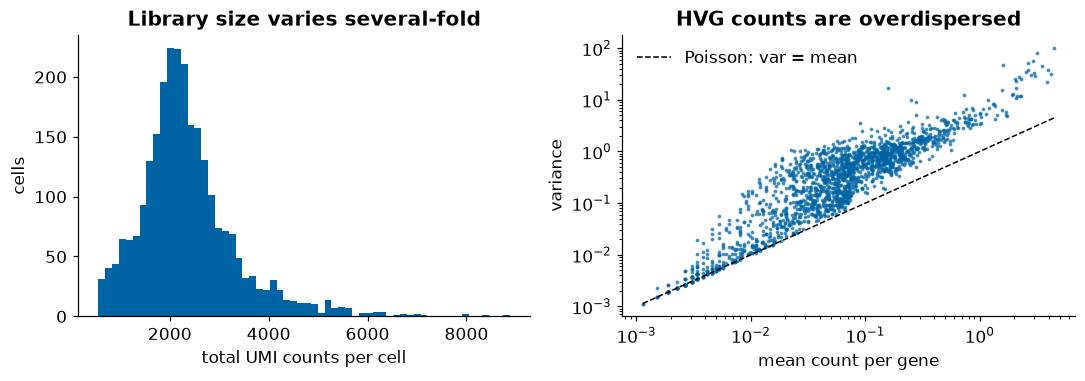

In [4]:
gm, gv = counts.mean(0), counts.var(0)
print(f"library size: min {lib.min():,.0f}, median {np.median(lib):,.0f}, max {lib.max():,.0f}")
print(f"{100 * (counts == 0).mean():.0f}% of the HVG count matrix is zero; largest count {counts.max():.0f}")
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
axs[0].hist(lib, bins=60, color=PALETTE[0])
axs[0].set(xlabel="total UMI counts per cell", ylabel="cells", title="Library size varies several-fold")
axs[1].loglog(gm, gv, ".", ms=3, color=PALETTE[0], alpha=0.6)
lim = np.array([gm.min(), gm.max()])
axs[1].loglog(lim, lim, "k--", lw=1, label="Poisson: var = mean")
axs[1].set(xlabel="mean count per gene", ylabel="variance", title="HVG counts are overdispersed")
axs[1].legend(); plt.tight_layout(); plt.show()

**Cell-type labels for evaluation only.** PCA → neighbor graph → Leiden clusters → annotate each cluster with the
marker-gene set that has the highest (z-scored) mean expression — the same procedure as L15.

In [5]:
MARKERS = {"CD4 T": ["IL7R", "CCR7"], "CD8 T": ["CD8A", "CD8B"], "NK": ["GNLY", "NKG7"], "B": ["MS4A1", "CD79A"],
           "CD14 mono": ["CD14", "LYZ"], "FCGR3A mono": ["FCGR3A", "MS4A7"], "DC": ["FCER1A", "CST3"],
           "Platelet": ["PPBP"]}
CTYPES = list(MARKERS)
CCOL = dict(zip(CTYPES, [PALETTE[0], PALETTE[4], PALETTE[2], PALETTE[1], PALETTE[5], PALETTE[3], "#7F4F24", "#1F2933"]))
b = adata.copy()
sc.pp.scale(b, max_value=10)
sc.tl.pca(b, n_comps=50, svd_solver="arpack", random_state=0)
sc.pp.neighbors(b, n_neighbors=10, n_pcs=40, random_state=0)
sc.tl.leiden(b, resolution=1.0, random_state=0, flavor="igraph", n_iterations=2, directed=False)
R = b.raw.to_adata()
Mk = pd.DataFrame({ct: np.asarray(R[:, [g for g in gs if g in R.var_names]].X.todense()).mean(1)
                   for ct, gs in MARKERS.items()})
Mk["cl"] = b.obs.leiden.values
G = Mk.groupby("cl", observed=True).mean()
ctype = b.obs.leiden.map(((G - G.mean()) / G.std()).idxmax(axis=1).to_dict()).astype(str).values
X_pca = b.obsm["X_pca"].astype(np.float32)
print(pd.Series(ctype).value_counts().to_dict())
del b, R


def cells(ax, E, s=4, legend=False):
    for c in CTYPES:
        m = ctype == c
        ax.scatter(E[m, 0], E[m, 1], s=s, color=CCOL[c], label=c, edgecolor="none")
    if legend:
        ax.legend(markerscale=3, fontsize=11, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)


def knn_acc(E, k=15):
    """5-fold CV accuracy of a 15-NN classifier predicting the marker-based cell type from an embedding."""
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    return cross_val_score(KNeighborsClassifier(k), E, ctype, cv=cv).mean()


pca_knn = knn_acc(X_pca[:, :K])
print(f"15-NN cell-type accuracy on 10 PCs: {100 * pca_knn:.1f}%")

{'CD4 T': 1173, 'CD14 mono': 427, 'B': 339, 'CD8 T': 275, 'FCGR3A mono': 211, 'NK': 163, 'DC': 37, 'Platelet': 13}
15-NN cell-type accuracy on 10 PCs: 96.8%


## 4. The model: encoder, reparameterization, decoder

- **Encoder** $q_\phi(\mathbf z\mid\mathbf x)$: MLP $d\to256\to128$, then two heads for $\boldsymbol\mu$ and $\log\boldsymbol\sigma^2$ (the log-variance keeps $\sigma>0$).
- **Reparameterization**: $\mathbf z=\boldsymbol\mu+\boldsymbol\sigma\odot\boldsymbol\epsilon$, $\boldsymbol\epsilon\sim\mathcal N(\mathbf 0,\mathbf I)$ — the randomness is an input, so gradients flow to $\phi$.
- **Decoder** $p_\theta(\mathbf x\mid\mathbf z)$: MLP $k\to128\to256\to d$ that outputs the mean $g_\theta(\mathbf z)$ of a unit-variance Gaussian,
  so $-\log p_\theta(\mathbf x\mid\mathbf z)=\tfrac12\|\mathbf x-g_\theta(\mathbf z)\|^2+\text{const}$.
- **KL term** (closed form, per cell): $\tfrac12\sum_j(\mu_j^2+\sigma_j^2-\log\sigma_j^2-1)$.
- Loss per minibatch: mean over cells of reconstruction $+\ \beta\cdot$KL (sum over genes and latent dimensions). $\beta=1$ is the negative ELBO.

`kind="ae"` turns the same network into a plain autoencoder (L17): $\mathbf z=\boldsymbol\mu$, no KL term.
`kind="nb"` is the count model of Section 7.

In [6]:
class VAE(nn.Module):
    def __init__(self, d, k=10, hidden=(256, 128), nb=False):
        super().__init__()
        h1, h2 = hidden
        self.enc = nn.Sequential(nn.Linear(d, h1), nn.ReLU(), nn.Linear(h1, h2), nn.ReLU())
        self.mu = nn.Linear(h2, k)
        self.logvar = nn.Linear(h2, k)
        self.dec = nn.Sequential(nn.Linear(k, h2), nn.ReLU(), nn.Linear(h2, h1), nn.ReLU(), nn.Linear(h1, d))
        if nb:
            self.log_theta = nn.Parameter(torch.zeros(d))     # gene-wise NB inverse dispersion (Section 7)

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)                  # the noise does not depend on phi
        return mu + torch.exp(0.5 * logvar) * eps

    def forward(self, x, sample=True):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar) if sample else mu
        return self.dec(z), mu, logvar


def kl_term(mu, logvar):
    """KL(N(mu, diag exp(logvar)) || N(0, I)), one value per sample."""
    return 0.5 * (mu ** 2 + logvar.exp() - logvar - 1).sum(1)


def nb_loglik(x, mu, theta, eps=1e-8):
    """log NB(x; mean mu, inverse dispersion theta), elementwise."""
    return (torch.lgamma(x + theta) - torch.lgamma(theta) - torch.lgamma(x + 1)
            + theta * (torch.log(theta + eps) - torch.log(theta + mu + eps))
            + x * (torch.log(mu + eps) - torch.log(theta + mu + eps)))


X_t, C_t, L_t = torch.tensor(Xlog), torch.tensor(counts), torch.tensor(lib)[:, None]

# 10% of the cells are held out to measure reconstruction error (the same split for every model)
va_idx = torch.randperm(n, generator=torch.Generator().manual_seed(0))[: n // 10]
print(f"train {n - len(va_idx):,} cells, held-out {len(va_idx):,} cells")

train 2,375 cells, held-out 263 cells


## 5. Training

One function trains all models of this notebook. It follows the lecture code line by line (same split, seed,
initialization and minibatch order), so the numbers match the slides. The three arguments `sample`, `beta`
(a number, or a function of the epoch) and `learn_var` exist for the *Try it yourself* exercises.
After training we report, on the held-out cells, the reconstruction MSE per gene (decoding $\boldsymbol\mu$), the KL per cell, and the number of
**active units**: latent dimensions whose posterior mean $\mu_j(\mathbf x)$ varies across cells (variance > 0.01).
Finally we decode 2,000 draws $\mathbf z\sim\mathcal N(\mathbf 0,\mathbf I)$ to test the model as a *generator*.

In [7]:
def train_pbmc(beta=1.0, k=K, kind="gauss", epochs=EPOCHS, seed=0, lr=1e-3, bs=128, sample=True, learn_var=False):
    """kind: 'gauss' (VAE, unit-variance Gaussian on log-normalized HVGs), 'ae' (deterministic AE, squared error),
    'nb' (VAE, negative binomial on raw counts with observed library size)."""
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    va, tr = perm[: n // 10], perm[n // 10:]
    torch.manual_seed(seed)
    m = VAE(d, k, nb=(kind == "nb"))
    if learn_var:
        m.log_s2 = nn.Parameter(torch.zeros(d))       # per-gene decoder log-variance (Try it yourself)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    beta_at = beta if callable(beta) else (lambda ep: beta)

    def losses(idx):
        x = X_t[idx]
        out, mu, logvar = m(x, sample=(sample and kind != "ae"))
        kl = kl_term(mu, logvar)
        if kind == "nb":
            rec = -nb_loglik(C_t[idx], L_t[idx] * torch.softmax(out, 1), m.log_theta.exp()).sum(1)
        elif learn_var:
            rec = 0.5 * ((x - out) ** 2 * torch.exp(-m.log_s2) + m.log_s2).sum(1)
        else:
            rec = 0.5 * ((x - out) ** 2).sum(1)      # -log N(x; out, I), constant dropped
        if kind == "ae":
            kl = torch.zeros_like(rec)
        return rec, kl

    hist = []
    for ep in range(epochs):
        m.train()
        sh = tr[torch.randperm(len(tr), generator=g)]
        tot = 0.0
        for i in range(0, len(sh), bs):
            idx = sh[i:i + bs]
            rec, kl = losses(idx)
            loss = (rec + beta_at(ep) * kl).mean()    # negative (beta-weighted) ELBO
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(idx)
        hist.append(tot / len(tr))
    m.eval()
    with torch.no_grad():
        mu, logvar = m.encode(X_t)
        rec_v, kl_v = losses(va)
        mse = float("nan") if kind == "nb" else float(((X_t[va] - m.dec(mu[va])) ** 2).mean())
        torch.manual_seed(123)
        xs = m.dec(torch.randn(2000, k))                              # decode draws from the prior
        if kind == "nb":
            xs = torch.log1p(torch.softmax(xs, 1) * 1e4)              # to the log-normalized scale
        au = mu.var(0).numpy()
    return dict(model=m, mu=mu.numpy(), sd=np.exp(0.5 * logvar.numpy()), kl_val=float(kl_v.mean()), mse_val=mse,
                active=int((au > 0.01).sum()), au=au, hist=np.array(hist), prior_dec=xs.numpy())


# "prior realism": median distance from decoded prior draws to the nearest real cell (20 PCs of log-expression),
# relative to the median nearest-neighbor distance between real cells
pca20 = PCA(20, random_state=0).fit(Xlog)
R20 = pca20.transform(Xlog)
nn_real = NearestNeighbors(n_neighbors=2).fit(R20)
base = np.median(nn_real.kneighbors(R20)[0][:, 1])

def prior_realism(Xdec):
    return float(np.median(nn_real.kneighbors(pca20.transform(Xdec), n_neighbors=1)[0][:, 0]) / base)

### 5a. Autoencoder vs. VAE with 2-D codes

With $k=2$ we can plot the latent space directly. Circles mark 1 and 2 standard deviations of the prior
$\mathcal N(\mathbf 0,\mathbf I)$. (These two models train for `EPOCHS_2D = 40` epochs instead of the lecture's 120 to save time;
the picture is the same.)

trained two 2-D models in 17 s


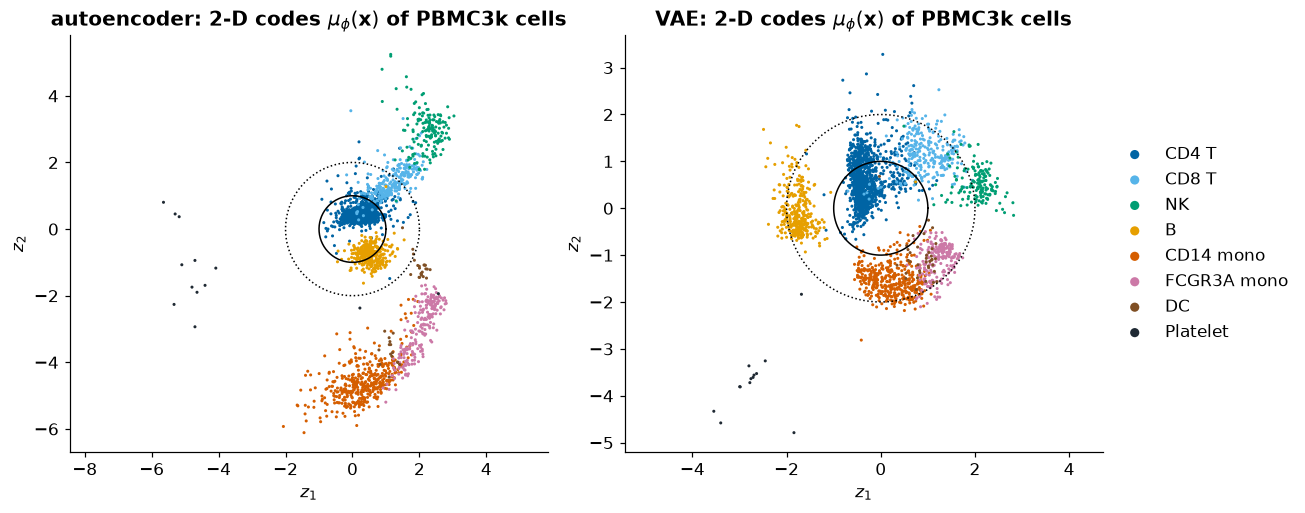

autoencoder : decoded prior draws lie 0.94 x the typical cell-cell distance from the nearest real cell
VAE         : decoded prior draws lie 0.84 x the typical cell-cell distance from the nearest real cell


In [8]:
t = time.time()
two_d = {name: train_pbmc(kind=kind, k=2, epochs=EPOCHS_2D) for name, kind in [("autoencoder", "ae"), ("VAE", "gauss")]}
print(f"trained two 2-D models in {time.time() - t:.0f} s")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
th = np.linspace(0, 2 * np.pi, 200)
for ax, (name, r) in zip(axes, two_d.items()):
    cells(ax, r["mu"], legend=(name == "VAE"))
    for rad in (1, 2):
        ax.plot(rad * np.cos(th), rad * np.sin(th), "k", lw=1, ls="-" if rad == 1 else ":")
    ax.set(title=f"{name}: 2-D codes $\\mu_\\phi(\\mathbf{{x}})$ of PBMC3k cells", xlabel="$z_1$", ylabel="$z_2$")
    ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()
for name, r in two_d.items():
    print(f"{name:12s}: decoded prior draws lie {prior_realism(r['prior_dec']):.2f} x the typical cell-cell distance "
          f"from the nearest real cell")

The AE's code scale and location are arbitrary; clusters spread out with empty space between them, so a draw from
$\mathcal N(\mathbf 0,\mathbf I)$ may land where no cell was ever encoded. The VAE's KL term packs the codes into the prior region.

## 6. Evaluation: 10-D models, AE vs. VAE and the effect of β

A plain AE and Gaussian VAEs with $\beta\in\{0, 1, 8\}$ (to fit the runtime target; `FULL_SWEEP = True`
adds 0.1, 0.5, 2 and 4 as on the slides), 120 epochs each. For each model: held-out reconstruction MSE (per gene), KL per cell, active units,
15-NN cell-type accuracy of the latent means, and the prior-realism ratio. About 40 s per model on a 4-thread CPU.

In [9]:
t = time.time()
res = {"AE": train_pbmc(kind="ae")}
for beta in BETAS:
    res[f"VAE β={beta:g}"] = train_pbmc(beta=beta)
print(f"trained {len(res)} models in {time.time() - t:.0f} s")
table = pd.DataFrame({name: {"held-out MSE": r["mse_val"], "KL (nats/cell)": r["kl_val"], "active units": r["active"],
                             "15-NN acc (%)": 100 * knn_acc(r["mu"]), "prior realism": prior_realism(r["prior_dec"])}
                      for name, r in res.items()}).T
table["active units"] = table["active units"].astype(int)
print(table.round({"held-out MSE": 4, "KL (nats/cell)": 1, "15-NN acc (%)": 1, "prior realism": 2}).to_string())

trained 4 models in 106 s


         held-out MSE  KL (nats/cell)  active units  15-NN acc (%)  prior realism
AE             0.2136             0.0            10           94.3           1.23
VAE β=0        0.2131           242.0            10           94.1           1.39
VAE β=1        0.2033             4.2             4           95.3           0.81
VAE β=8        0.2090             1.3             1           87.3           0.79


**Numbers vs. the slides** (lecture, 120 epochs, CPU): active units for β = 0, 0.1, 0.5, 1, 2, 4, 8 are
10, 10, 4, 4, 2, 2, 1; the lowest held-out MSE is at β = 1 (0.2033); 15-NN accuracy AE 94.4%, VAE (β = 1) 95.3%,
PCA (10 PCs) 96.8%. The table above reproduces these (the default run trains three of the seven β values; set
`FULL_SWEEP = True` for the rest). The AE's 15-NN accuracy prints as 94.3% here vs. 94.4% on the slides (and the NB VAE
below 92.7% vs. 92.6%): about 3 of 2,638 cells, from floating-point differences between the machine that built the
slides and this one; the port is line-for-line the lecture code. The same applies to the extra β values of
`FULL_SWEEP`: on our 4-thread Linux CPU (both this notebook and the lecture file) β = 0.1 / 0.5 / 2 / 4 give
10 / 4 / **3** / **5** active units instead of the slides' 10 / 4 / 2 / 2. For β = 4 the three extra "active" units have
variances 0.05, 0.018 and 0.011, just above the 0.01 threshold, next to two units at ≈ 0.9: active-unit counts near the
threshold are fragile, and the trend (fewer units as β grows) is what matters.

Read the table:
- **β = 0** keeps every latent dimension active and a large KL, but nothing organizes the codes — like the AE. Its
  held-out error is *higher* than at β = 1: without the KL term the model overfits the training cells. The AE also
  overfits.
- Increasing β lowers the KL; dimensions **switch off** (their posterior becomes the prior for every cell:
  *posterior collapse* of those units). At β = 8 one unit is left and reconstructions approach the average cell.
- Decoded prior draws of the VAE are closer to real cells than those of the AE, whose codes were never tied to $\mathcal N(\mathbf 0,\mathbf I)$.
- The unit-variance Gaussian decoder fixes the noise level; changing σ² is equivalent to changing β.

Which dimensions are active? Variance of each $\mu_j(\mathbf x)$ across cells:

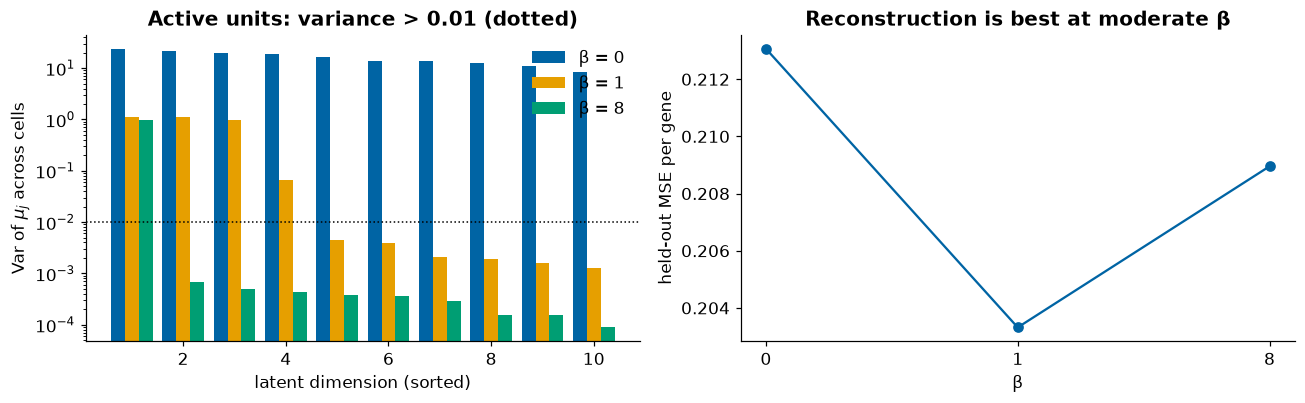

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
sel = [bb for bb in [0.0, 1.0, 8.0] if bb in BETAS]
for i, beta in enumerate(sel):
    v = np.sort(res[f"VAE β={beta:g}"]["au"])[::-1]
    axs[0].bar(np.arange(1, K + 1) + (i - 1) * 0.27, v, 0.27, label=f"β = {beta:g}", color=PALETTE[i])
axs[0].axhline(0.01, color="k", ls=":", lw=1)
axs[0].set(yscale="log", xlabel="latent dimension (sorted)", ylabel="Var of $\\mu_j$ across cells",
           title="Active units: variance > 0.01 (dotted)")
axs[0].legend()
vk = [(bb, res[f"VAE β={bb:g}"]) for bb in BETAS]
axs[1].plot(range(len(vk)), [r["mse_val"] for _, r in vk], "o-", color=PALETTE[0])
axs[1].set_xticks(range(len(vk)), [f"{bb:g}" for bb, _ in vk])
axs[1].set(xlabel="β", ylabel="held-out MSE per gene", title="Reconstruction is best at moderate β")
plt.tight_layout(); plt.show()

## 7. *(CS284A)* A count likelihood: negative-binomial VAE (a simplified scVI)

scVI (Lopez et al., *Nature Methods* 2018) models raw counts with a (zero-inflated) negative binomial whose mean is
library size × normalized expression, and conditions on batch. We keep the core idea and simplify: NB (no zero
inflation), observed library size $\ell_n$, a single batch.

$$x_{ng}\sim\mathrm{NB}(\mu_{ng}=\ell_n\rho_{ng},\ \theta_g),\qquad \boldsymbol\rho_n=\mathrm{softmax}(g_\theta(\mathbf z_n)),\qquad \mathrm{Var}[x]=\mu+\mu^2/\theta.$$

The encoder still sees $\log(1+\text{normalized counts})$; only the likelihood changes.

In [11]:
t = time.time()
nb = train_pbmc(kind="nb", beta=1.0)
theta = nb["model"].log_theta.exp().detach().numpy()
print(f"NB VAE trained in {time.time() - t:.0f} s; active units {nb['active']}; KL {nb['kl_val']:.1f} nats/cell; "
      f"15-NN accuracy {100 * knn_acc(nb['mu']):.1f}%")
print(f"learned inverse dispersion theta: median {np.median(theta):.2f} (small theta = strongly overdispersed)")

NB VAE trained in 34 s; active units 10; KL 8.3 nats/cell; 15-NN accuracy 92.7%
learned inverse dispersion theta: median 0.77 (small theta = strongly overdispersed)


## 8. Visualization: latent spaces side by side (UMAP)

UMAP of each 10-D embedding (PCA, AE, Gaussian VAE with β = 1, NB VAE), with the 15-NN accuracy in the title.

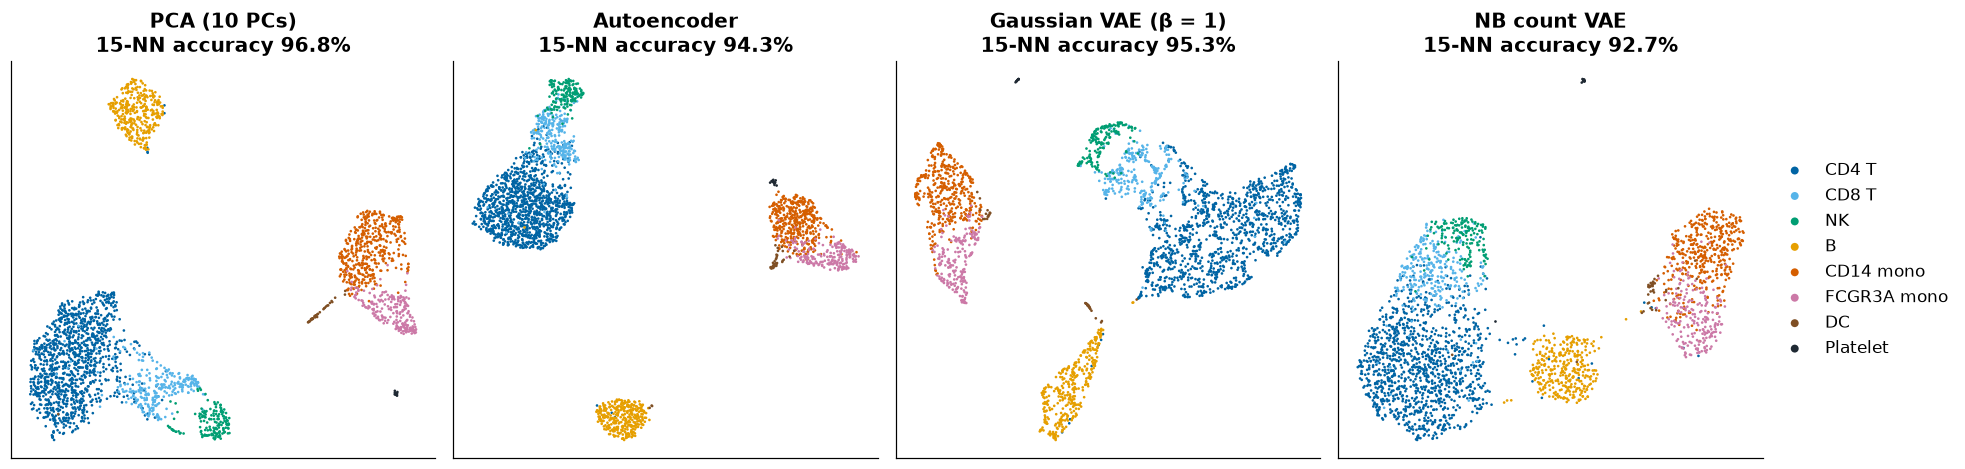

UMAPs in 47 s
15-NN accuracy: {'PCA (10 PCs)': '96.8%', 'Autoencoder': '94.3%', 'Gaussian VAE (β = 1)': '95.3%', 'NB count VAE': '92.7%'}


In [12]:
import umap
t = time.time()
embs = {"PCA (10 PCs)": X_pca[:, :K], "Autoencoder": res["AE"]["mu"], "Gaussian VAE (β = 1)": res["VAE β=1"]["mu"],
        "NB count VAE": nb["mu"]}
acc = {name: knn_acc(E) for name, E in embs.items()}
fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
for ax, (name, E) in zip(axes, embs.items()):
    U2 = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0).fit_transform(E)
    cells(ax, U2, s=3, legend=(name == "NB count VAE"))
    ax.set(title=f"{name}\n15-NN accuracy {100 * acc[name]:.1f}%", xticks=[], yticks=[])
plt.tight_layout(); plt.show()
print(f"UMAPs in {time.time() - t:.0f} s")
print("15-NN accuracy:", {k_: f"{100 * v:.1f}%" for k_, v in acc.items()})

Slides: PCA 96.8%, AE 94.4%, VAE 95.3%, NB VAE 92.6% (see the note in Section 6 on the ±0.1-point differences).

**Caution.** The labels come from Leiden clusters computed on PCA, so PCA has a built-in advantage in this
accuracy metric. All embeddings separate the major cell types; the differences are small on one clean, single-batch
data set. VAEs matter more when we need a generative model (sampling, denoising, uncertainty) or when depth and
batch must be modeled explicitly (scVI).

## 9. Generating images: a convolutional VAE on BloodMNIST

**Dataset.** BloodMNIST (MedMNIST v2; Yang et al., *Scientific Data* 10, 41, 2023; license CC BY 4.0): 28 × 28 RGB
micrographs of individual blood cells from peripheral blood smears (Acevedo et al., *Data in Brief* 2020), 8 classes
(L09). **One sample = one cell image**; 11,959 training and 3,421 test images. Labels are **not** used for training.

Encoder: two stride-2 convolutions (28 → 14 → 7) and a dense layer; decoder mirrors it with transposed
convolutions; $k = 16$. Pixels lie in [0, 1]; we use binary cross-entropy as the reconstruction term (a common practical
choice for image VAEs).

**Runtime and the two configurations.** The lecture's model (32/64 channels, 1.69 M parameters, batch 128, η = 10⁻³,
20 epochs) takes 2.5–12 minutes on a 4-thread CPU, so it runs only when a GPU/MPS is available (`BLOOD_FULL`). On a CPU
we train a **half-width** version (16/32 channels, 0.84 M parameters) with batch 64, η = 2·10⁻³ for 10 epochs (about 40 s).
With the same seed it reaches about the same test error as the lecture model (per-pixel MSE ≈ 0.009 and KL ≈ 10 nats per
image in our runs of both); simply training the lecture model for fewer epochs on a CPU gave much blurrier samples.
Numbers therefore differ slightly from the slide notes. The executed copy of this notebook ran the lecture configuration
on an NVIDIA GPU (22 s): per-pixel MSE 0.0087, KL 10.7 nats per image, 16 of 16 latent units active.

In [13]:
blood = np.load(DATA / "bloodmnist.npz")
Btr = torch.tensor(blood["train_images"]).permute(0, 3, 1, 2).float() / 255
Bte = torch.tensor(blood["test_images"]).permute(0, 3, 1, 2).float() / 255
yte = blood["test_labels"][:, 0]
BCLASSES = ["basophil", "eosinophil", "erythroblast", "immature gran.", "lymphocyte", "monocyte", "neutrophil",
            "platelet"]
print("train", tuple(Btr.shape), "test", tuple(Bte.shape))


class ConvVAE(nn.Module):
    def __init__(self, k=16, c1=32, c2=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Conv2d(3, c1, 4, 2, 1), nn.ReLU(),            # 28 -> 14
                                 nn.Conv2d(c1, c2, 4, 2, 1), nn.ReLU(),           # 14 -> 7
                                 nn.Flatten(), nn.Linear(c2 * 7 * 7, 256), nn.ReLU())
        self.mu, self.logvar = nn.Linear(256, k), nn.Linear(256, k)
        self.dec = nn.Sequential(nn.Linear(k, 256), nn.ReLU(), nn.Linear(256, c2 * 7 * 7), nn.ReLU(),
                                 nn.Unflatten(1, (c2, 7, 7)),
                                 nn.ConvTranspose2d(c2, c1, 4, 2, 1), nn.ReLU(),       # 7 -> 14
                                 nn.ConvTranspose2d(c1, 3, 4, 2, 1))                   # 14 -> 28 (logits)

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)                # reparameterization
        return self.dec(z), mu, logvar


def blood_losses(m, x):
    logits, mu, logvar = m(x)
    rec = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum((1, 2, 3))
    return rec, kl_term(mu, logvar)


KB = 16
if BLOOD_FULL:   # lecture configuration
    C1, C2, BLOOD_EPOCHS, BS, LR = 32, 64, 20, 128, 1e-3
else:            # reduced CPU configuration
    C1, C2, BLOOD_EPOCHS, BS, LR = 16, 32, 10, 64, 2e-3
torch.manual_seed(0)
cvae = ConvVAE(KB, C1, C2)
print(f"conv VAE: {sum(p.numel() for p in cvae.parameters()):,} parameters, {BLOOD_EPOCHS} epochs, batch {BS}")
cvae.to(DEV)
opt = torch.optim.Adam(cvae.parameters(), lr=LR)
g = torch.Generator().manual_seed(0)
bhist = []
t = time.time()
for ep in range(BLOOD_EPOCHS):
    cvae.train()
    p = torch.randperm(len(Btr), generator=g)
    tot = np.zeros(2)
    for i in range(0, len(Btr), BS):
        x = Btr[p[i:i + BS]].to(DEV)
        rec, kl = blood_losses(cvae, x)
        loss = (rec + kl).mean()                                                # negative ELBO
        opt.zero_grad(); loss.backward(); opt.step()
        tot += [rec.sum().item(), kl.sum().item()]
    bhist.append(tot / len(Btr))
    if ep % 2 == 1 or ep == BLOOD_EPOCHS - 1:
        print(f"epoch {ep + 1:2d}: reconstruction {bhist[-1][0]:.1f}, KL {bhist[-1][1]:.1f} nats/image "
              f"({time.time() - t:.0f} s)")
cvae.eval().cpu();

with torch.no_grad():
    mu_te, _ = cvae.encode(Bte)
    rec_te = torch.sigmoid(cvae.dec(mu_te))
    torch.manual_seed(0)
    r_, k_ = blood_losses(cvae, Bte)
print(f"test set: reconstruction MSE per pixel {((rec_te - Bte) ** 2).mean():.4f}; ELBO {-(r_ + k_).mean():.0f} nats "
      f"per image (KL {k_.mean():.1f}); {int((mu_te.var(0) > 0.01).sum())} of {KB} latent units active")

train (11959, 3, 28, 28) test (3421, 3, 28, 28)
conv VAE: 1,690,339 parameters, 20 epochs, batch 128


epoch  2: reconstruction 1263.7, KL 1.7 nats/image (2 s)


epoch  4: reconstruction 1233.6, KL 4.5 nats/image (4 s)


epoch  6: reconstruction 1224.6, KL 5.6 nats/image (6 s)


epoch  8: reconstruction 1217.4, KL 7.2 nats/image (8 s)


...

epoch 14: reconstruction 1209.1, KL 9.0 nats/image (16 s)


epoch 16: reconstruction 1207.4, KL 9.5 nats/image (18 s)


epoch 18: reconstruction 1205.1, KL 10.2 nats/image (20 s)


epoch 20: reconstruction 1203.6, KL 10.6 nats/image (22 s)


test set: reconstruction MSE per pixel 0.0087; ELBO -1215 nats per image (KL 10.7); 16 of 16 latent units active


Training curves: the reconstruction term falls fast, while the KL keeps rising slowly as the encoder puts more
information into $\mathbf z$ — the two terms trade off throughout training.

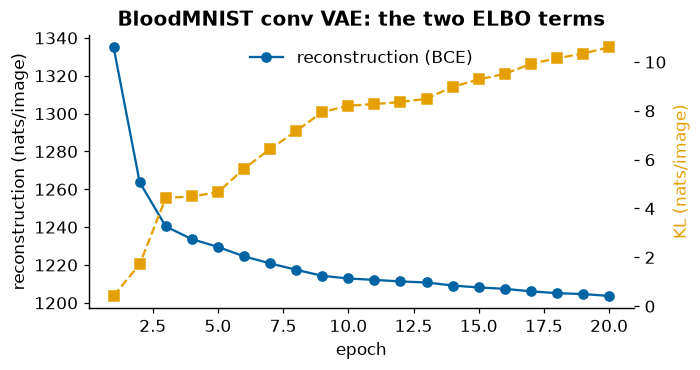

In [14]:
bh = np.array(bhist)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(np.arange(1, len(bh) + 1), bh[:, 0], "o-", color=PALETTE[0], label="reconstruction (BCE)")
ax.set(xlabel="epoch", ylabel="reconstruction (nats/image)", title="BloodMNIST conv VAE: the two ELBO terms")
ax2 = ax.twinx()
ax2.plot(np.arange(1, len(bh) + 1), bh[:, 1], "s--", color=PALETTE[1], label="KL")
ax2.set_ylabel("KL (nats/image)", color=PALETTE[1])
ax.legend(loc="upper center"); plt.tight_layout(); plt.show()

**Samples and reconstructions.** Decode 32 draws $\mathbf z\sim\mathcal N(\mathbf 0,\mathbf I)$ into new cell images.

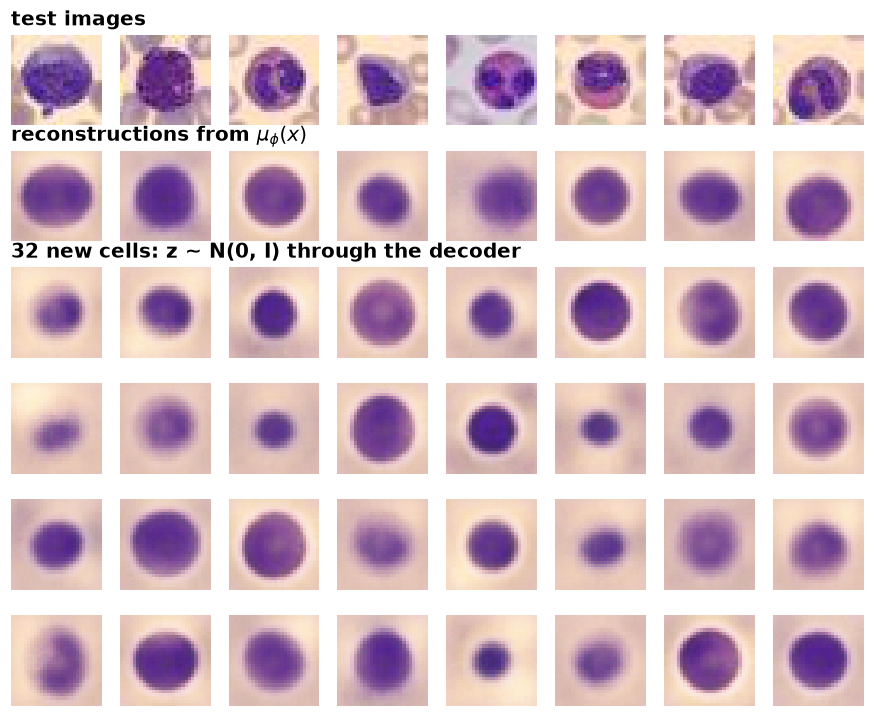

In [15]:
def show_row(axs, imgs):
    for ax, im in zip(axs, imgs):
        ax.imshow(np.clip(im.permute(1, 2, 0).numpy(), 0, 1)); ax.axis("off")

with torch.no_grad():
    torch.manual_seed(7)
    samples = torch.sigmoid(cvae.dec(torch.randn(32, KB)))
fig, axs = plt.subplots(6, 8, figsize=(10, 8))
show_row(axs[0], Bte[:8]); show_row(axs[1], rec_te[:8])
for r in range(4):
    show_row(axs[2 + r], samples[8 * r: 8 * r + 8])
axs[0, 0].set_title("test images", loc="left"); axs[1, 0].set_title("reconstructions from $\\mu_\\phi(x)$", loc="left")
axs[2, 0].set_title("32 new cells: z ~ N(0, I) through the decoder", loc="left")
plt.tight_layout(); plt.show()

**Latent interpolation.** Encode two test cells and decode $\mathbf z_t=(1-t)\,\boldsymbol\mu_\phi(\mathbf x_a)+t\,\boldsymbol\mu_\phi(\mathbf x_b)$
for 8 values of $t\in[0,1]$ (the real cells are at both ends). A smooth morph does **not** mean the intermediate
images are biological intermediates: lymphocyte → neutrophil is not a differentiation path.

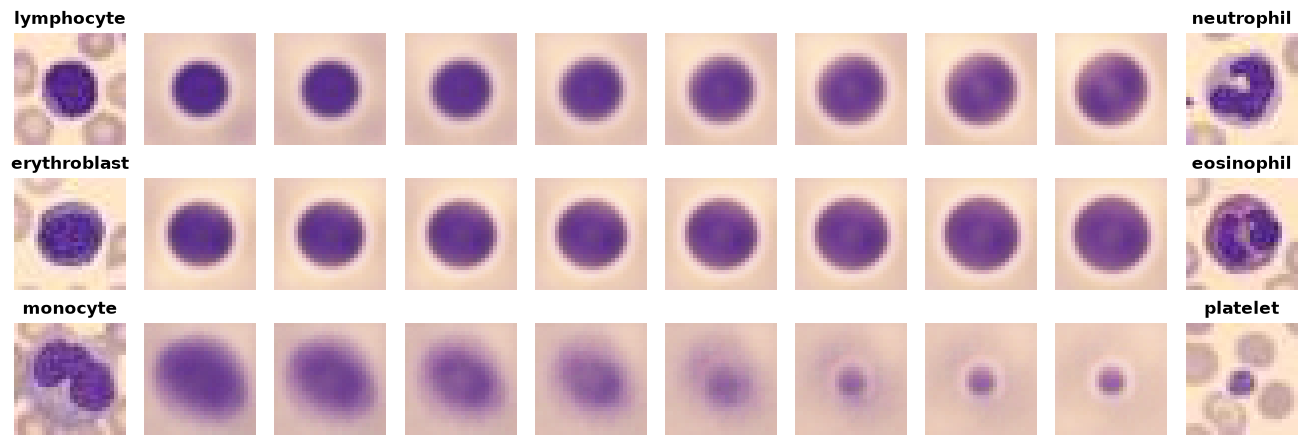

In [16]:
fig, axs = plt.subplots(3, 10, figsize=(12, 4.2))
with torch.no_grad():
    for r, (a, b_) in enumerate([(4, 6), (2, 1), (5, 7)]):
        ia, ib = int(np.where(yte == a)[0][0]), int(np.where(yte == b_)[0][0])
        ts = torch.linspace(0, 1, 8)[:, None]
        zs = (1 - ts) * mu_te[ia] + ts * mu_te[ib]
        show_row(axs[r], [Bte[ia], *torch.sigmoid(cvae.dec(zs)), Bte[ib]])
        axs[r, 0].set_title(BCLASSES[a], fontsize=11); axs[r, -1].set_title(BCLASSES[b_], fontsize=11)
plt.tight_layout(); plt.show()

## 10. Biological interpretation
- The VAE's KL term turns the latent space into a **known distribution**: we can sample from it, interpolate in it,
  and codes drawn from the prior decode to something cell-like. A plain AE compresses as well (or better on the
  training cells) but gives no such guarantee.
- β controls how much information the code may carry. Too large and dimensions collapse to the prior; too small and
  the latent space loses its regularity (and the model overfits). The "right" β depends on the decoder's noise model.
- For single-cell data the likelihood matters: counts, library size and batch belong in the model (scVI). The latent
  posterior means then serve as the embedding for clustering, UMAP and data integration; decoded expression gives
  denoised values and differential-expression tests.
- Generated images are blurry: the decoder outputs a mean image under a factorized pixel likelihood. Sharper
  generative models (diffusion, flow matching) are the topic of L19.

In [17]:
print(f"total runtime: {time.time() - T0:.0f} s")

total runtime: 255 s


## 11. Try it yourself
1. Replace $\mathbf z=\boldsymbol\mu+\boldsymbol\sigma\odot\boldsymbol\epsilon$ by $\mathbf z=\boldsymbol\mu$. What happens to the KL term and to prior samples?
   *(Call `r = train_pbmc(beta=1.0, sample=False)` and compare `r["kl_val"]`, `r["sd"]`, `r["active"]` and
   `prior_realism(r["prior_dec"])` with the β = 1 VAE. Hint: σ no longer affects the reconstruction, so what does the KL term do with it?)*
2. Anneal β from 0 to 1 over the first 30 epochs. More active units? *(`train_pbmc(beta=lambda ep: min(1.0, ep / 30))`)*
3. Learn a per-gene decoder variance. How does the effective β change? *(`train_pbmc(learn_var=True)`; compare
   `active` and `np.exp(r["model"].log_s2.detach().numpy())` — a noise variance σ² < 1 acts like β = σ² for that gene.)*
4. Increase the BloodMNIST latent dimension `KB` to 64 (Section 9). Do reconstructions improve? Do prior samples?
5. Interpolate between two PBMC cells of different types (e.g., B → CD14 mono) with the 10-D β = 1 VAE
   (`res["VAE β=1"]["model"]`), decode, and plot the marker genes MS4A1 and LYZ along the path.
6. *(CS284A)* Add a zero-inflation head to the NB VAE (ZINB). Does the held-out NB log-likelihood improve on this UMI
   data set (Svensson, *Nat. Biotechnol.* 2020)?